# 📊 Real-World Pandas Project: Netflix User Viewing Activity

We'll work with a real-world-like dataset mimicking Netflix viewing history to explore full capabilities of Pandas for:
- Data cleaning
- Date/time parsing
- Feature engineering
- Aggregations, GroupBy, Pivoting
- Plotting
- Handling missing data and more

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 🔽 Load Dataset (Synthetic Netflix Viewing History)

In [3]:
# Generate synthetic viewing data
np.random.seed(0)
user_ids = [f'user_{i}' for i in range(1, 6)]
titles = ['Breaking Bad', 'The Witcher', 'Dark', 'Stranger Things', 'Ozark']
genres = ['Drama', 'Fantasy', 'Sci-Fi', 'Thriller', 'Crime']
start_date = pd.to_datetime('2023-01-01')

records = []
for _ in range(100):
    uid = np.random.choice(user_ids)
    title_idx = np.random.randint(0, len(titles))
    title = titles[title_idx]
    genre = genres[title_idx]
    date = start_date + pd.Timedelta(days=np.random.randint(0, 180))
    duration = np.random.randint(10, 90)
    records.append([uid, title, genre, date, duration])

df = pd.DataFrame(records, columns=['user_id', 'title', 'genre', 'watch_date', 'watch_duration'])
df.head()

,user_id,title,genre,watch_date,watch_duration
0,user_5,Breaking Bad,Drama,2023-03-09,77
1,user_2,Stranger Things,Thriller,2023-01-22,46
2,user_1,Breaking Bad,Drama,2023-05-21,68
3,user_2,Breaking Bad,Drama,2023-03-23,47
4,user_2,Breaking Bad,Drama,2023-01-10,30


## 🧹 Data Cleaning & Feature Engineering

In [6]:
# Convert to datetime
df['watch_date'] = pd.to_datetime(df['watch_date'])

# Extract year, month, weekday
df['year'] = df['watch_date'].dt.year
df['month'] = df['watch_date'].dt.month
df['weekday'] = df['watch_date'].dt.day_name()
df.head()

,user_id,title,genre,watch_date,watch_duration,year,month,weekday
0,user_5,Breaking Bad,Drama,2023-03-09,77,2023,3,Thursday
1,user_2,Stranger Things,Thriller,2023-01-22,46,2023,1,Sunday
2,user_1,Breaking Bad,Drama,2023-05-21,68,2023,5,Sunday
3,user_2,Breaking Bad,Drama,2023-03-23,47,2023,3,Thursday
4,user_2,Breaking Bad,Drama,2023-01-10,30,2023,1,Tuesday


## 📊 GroupBy Analysis - Average Watch Duration per Genre

In [8]:
genre_stats = df.groupby('genre')['watch_duration'].agg(['count', 'mean', 'median'])
genre_stats

,count,mean,median
genre,,,
Crime,18,53.000000,53.5
Drama,24,46.458333,46.5
Fantasy,21,52.190476,51.0
Sci-Fi,16,40.750000,41.0
Thriller,21,46.857143,46.0


## 📌 Pivot Table: Monthly Watch Time per Genre

In [ ]:
pivot_df = pd.pivot_table(df, values='watch_duration', index='month', columns='genre', aggfunc='sum')
pivot_df

## 🪄 Using `apply()`: Label Long vs Short Viewing Sessions

In [10]:
df['session_type'] = df['watch_duration'].apply(lambda x: 'Long' if x > 45 else 'Short')
df.head()

,user_id,title,genre,watch_date,watch_duration,year,month,weekday,session_type
0,user_5,Breaking Bad,Drama,2023-03-09,77,2023,3,Thursday,Long
1,user_2,Stranger Things,Thriller,2023-01-22,46,2023,1,Sunday,Long
2,user_1,Breaking Bad,Drama,2023-05-21,68,2023,5,Sunday,Long
3,user_2,Breaking Bad,Drama,2023-03-23,47,2023,3,Thursday,Long
4,user_2,Breaking Bad,Drama,2023-01-10,30,2023,1,Tuesday,Short


## 📈 Visualization: Watch Duration Trends by Genre

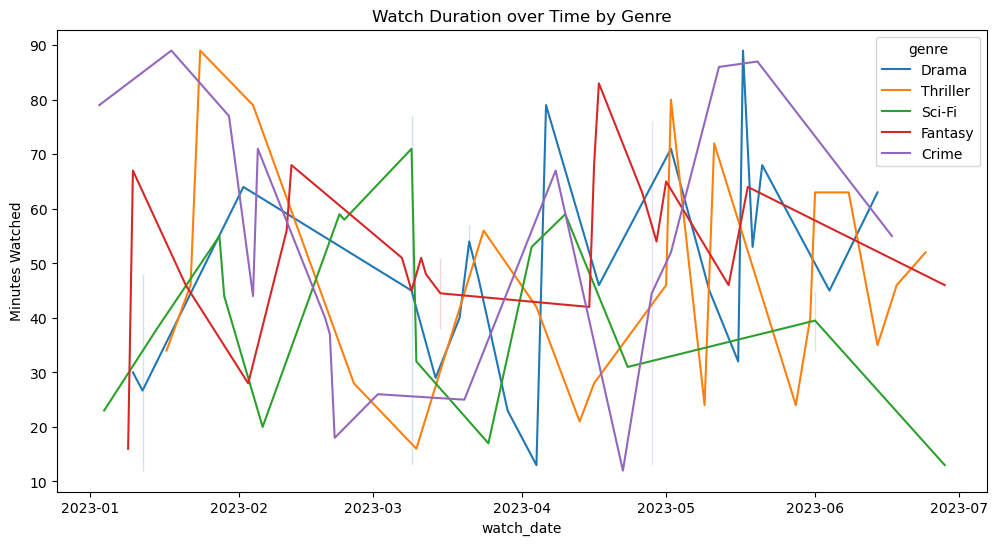

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='watch_date', y='watch_duration', hue='genre')
plt.title('Watch Duration over Time by Genre')
plt.ylabel('Minutes Watched')
plt.show()

## 🤔 Interview-Level Questions

**Q1:** How would you get top 3 most watched shows by total watch time?

**A:**

In [ ]:
df.groupby('title')['watch_duration'].sum().sort_values(ascending=False).head(3)

**Q2:** What's the average session time on weekends vs weekdays?

**A:**

In [ ]:
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])
df.groupby('is_weekend')['watch_duration'].mean()